In [1]:
import numpy as np               # numerical computing library
import matplotlib.pyplot as plt  # plotting library
import os                        # operating system interface

os.chdir(r'C:/Users/Giannis/.vscode/02_monte_carlo_simulation_toolkit')  # set working directory

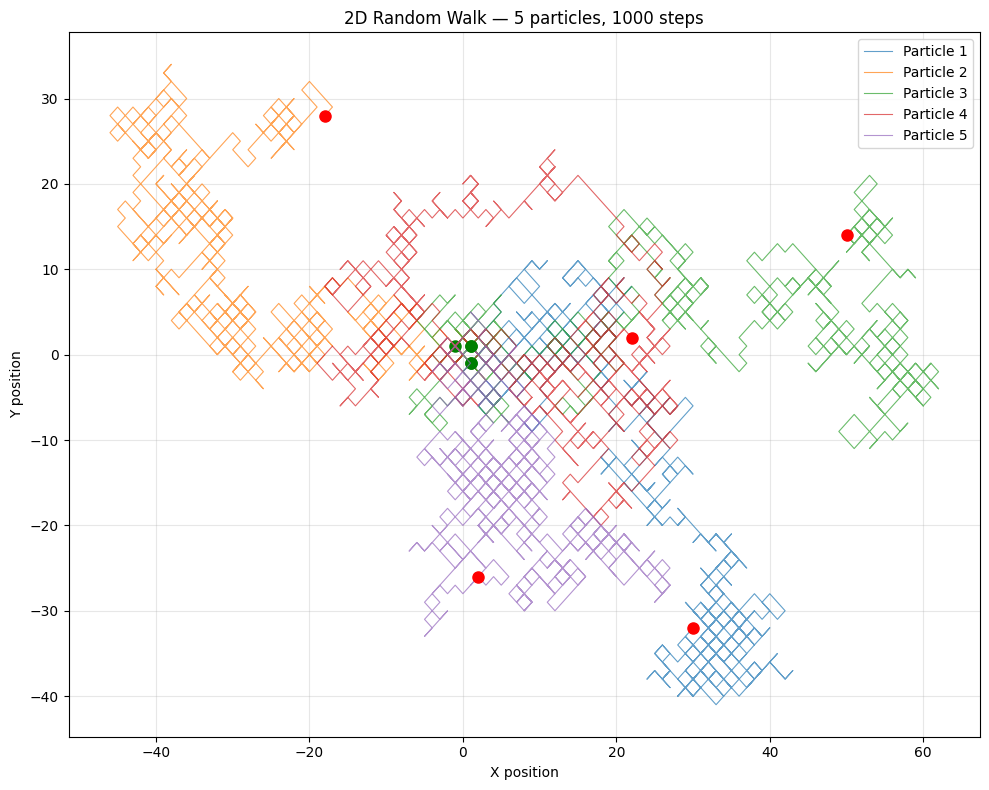

In [ ]:
# Parameters
n_steps = 1000   # number of steps each particle takes
n_walkers = 5    # number of independent particles to simulate

plt.figure(figsize=(10, 8))  # create figure

for i in range(n_walkers):
    
    # random steps in x and y — each step is either -1 or +1

    steps_x = np.random.choice([-1, 1], n_steps)
    steps_y = np.random.choice([-1, 1], n_steps)

    # cumulative sum converts individual steps into actual positions
    # e.g. steps [1,-1,1,1] → positions [1,0,1,2]

    x = np.cumsum(steps_x)
    y = np.cumsum(steps_y)

    plt.plot(x, y, alpha=0.7, linewidth=0.8,
             label=f'Particle {i+1}')          # plot particle path
    plt.plot(x[0], y[0], 'go', markersize=8)   # green dot = starting position
    plt.plot(x[-1], y[-1], 'ro', markersize=8) # red dot = final position

plt.title(f'2D Random Walk — {n_walkers} particles, {n_steps} steps')
plt.xlabel('X position')         # x axis label
plt.ylabel('Y position')         # y axis label
plt.legend()                     # show particle labels
plt.grid(True, alpha=0.3)        # light grid for readability
plt.tight_layout()               # auto adjust spacing
plt.savefig('results/03_random_walk_paths.png', bbox_inches='tight')  # save
plt.show()

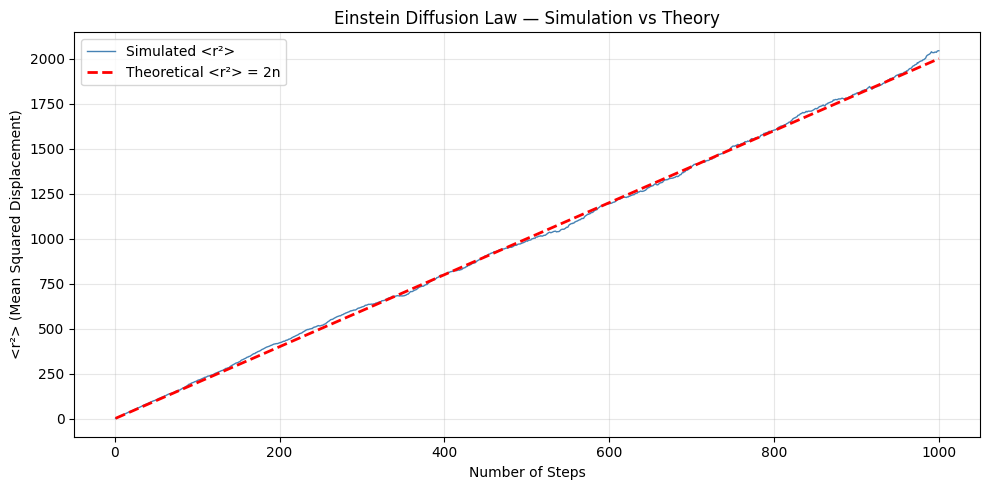

In [ ]:
n_steps = 1000     # number of steps per walker
n_walkers = 1000   # number of walkers — more = smoother average

# === EFFICIENCY IMPROVEMENT — fully vectorized with NumPy ===
# Old approach: Python loop over 1000 walkers — slow
# New approach: generate all walkers at once as a 2D array — fast

# generate all steps at once — shape (n_walkers, n_steps)

steps_x = np.random.choice([-1, 1], size=(n_walkers, n_steps))
steps_y = np.random.choice([-1, 1], size=(n_walkers, n_steps))

# cumulative sum along steps axis (axis=1) gives positions for all walkers

x = np.cumsum(steps_x, axis=1)  # shape (n_walkers, n_steps)
y = np.cumsum(steps_y, axis=1)  # shape (n_walkers, n_steps)

# mean squared displacement — r² = x² + y² for each walker at each step

r_squared = x**2 + y**2         # shape (n_walkers, n_steps)

# average r² across all walkers at each step

mean_r_squared = np.mean(r_squared, axis=0)  # shape (n_steps,)

steps = np.arange(1, n_steps + 1)  # step numbers 1 to 1000

plt.figure(figsize=(10, 5))
plt.plot(steps, mean_r_squared, color='steelblue',
         linewidth=1, label='Simulated <r²>')        # simulation result
plt.plot(steps, 2 * steps, 'r--', linewidth=2,
         label='Theoretical <r²> = 2n')              # Einstein prediction
# factor of 2 comes from 2 dimensions (x and y contribute equally)

plt.xlabel('Number of Steps')                        # x axis label
plt.ylabel('<r²> (Mean Squared Displacement)')        # y axis label
plt.title('Einstein Diffusion Law — Simulation vs Theory')
plt.legend()                                         # show labels
plt.grid(True, alpha=0.3)                            # light grid
plt.tight_layout()                                   # auto adjust spacing
plt.savefig('results/03_diffusion_law.png', bbox_inches='tight')  # save
plt.show()